In this notebook, we explore the number of templates stuff

In [1]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import matplotlib.ticker as mticker
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18
import glob
from matplotlib.lines import Line2D

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code/nebular_stuff'))

sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code/stacking_analysis'))


from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs, process_img
from desi_lowz_funcs import calc_normalized_dist, sdss_rgb, get_scrollable_pdfs
from desi_lowz_funcs import find_objects_nearby, print_radecs
# from construct_dwarf_galaxy_catalogs import process_sga_matches

import warnings
from astropy.wcs import FITSFixedWarning

from desi_lowz_funcs import plot_2d_dist, make_subplots

# Suppress just FITSFixedWarning
warnings.filterwarnings('ignore', category=FITSFixedWarning)

from sfr_and_metallicity import compute_o32, compute_r32
from sfr_and_metallicity import line_snr_mask
from catalog_paper_plots import make_cmap
from catalog_paper_plots import make_cmap
import cmasher as cmr
from scipy.stats import gaussian_kde

from pn_functions import compute_direct_metallicities

%load_ext autoreload
%autoreload 2




In [2]:

import matplotlib as mpl

mpl.rcParams.update({
    # --- Fonts (your existing sizes + cmr10 serif from new style) ---
    'font.family':                 'serif',
    'font.serif':                  'cmr10',
    'font.size':                   11,
    'mathtext.fontset':            'cm',
    'axes.unicode_minus':          False,
    'axes.formatter.use_mathtext': True,
    'axes.labelsize':              12,
    'axes.titlesize':              12,
    'xtick.labelsize':             10,
    'ytick.labelsize':             10,
    'legend.fontsize':             11,

    # --- Axes ---
    'axes.linewidth':              1.0,
    'axes.xmargin':                0.05,

    # --- X ticks: in, all sides, minor ticks on ---
    'xtick.direction':             'in',
    'xtick.top':                   True,
    'xtick.minor.visible':         True,
    'xtick.major.top':             True,
    'xtick.minor.top':             True,
    'xtick.major.size':            3.5,
    'xtick.minor.size':            2.0,
    'xtick.major.width':           1.0,
    'xtick.minor.width':           0.8,
    'xtick.major.pad':             4,
    'xtick.minor.pad':             4,

    # --- Y ticks: in, all sides, minor ticks on ---
    'ytick.direction':             'in',
    'ytick.right':                 True,
    'ytick.minor.visible':         True,
    'ytick.major.right':           True,
    'ytick.minor.right':           True,
    'ytick.major.size':            3.5,
    'ytick.minor.size':            2.0,
    'ytick.major.width':           1.0,
    'ytick.minor.width':           0.8,
    'ytick.major.pad':             4,
    'ytick.minor.pad':             4,

    # --- Legend ---
    'legend.frameon':              False,
    'legend.edgecolor':            'k',
    'legend.framealpha':           0,

    # --- Figure / savefig / misc ---
    'figure.facecolor':            'w',
    'image.aspect':                'auto',
    'image.cmap':                  'magma',
    'savefig.format':              'pdf',
    'savefig.bbox':                'standard',
    'savefig.dpi':                 300,
    'savefig.transparent':         False,
    'errorbar.capsize':            0,
    'lines.markersize':            5,
    'hist.bins':                   'auto',
})


MARGIN_LABEL  = 0.9   # edge with axis label + tick labels
MARGIN_TICKS  = 0.45  # edge with only tick labels (no axis label)
MARGIN_PAD    = 0.2   # edge with nothing
MARGIN_SHARED = 0.1   # gap between panels sharing an axis
MARGIN_SPLIT  = 0.7   # gap between panels with independent axes
MARGIN_CBAR   = 1.1   # edge with a colorbar



In [3]:
from astropy.table import Table
tab = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/ntemplate_scan/ntemplate_scan_summary.csv")
n_arr = tab["n_templates"]

In [28]:
path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/ncomponent_scan/pca_scan_per_component.npz"
d = np.load(path)

# See what's inside
print(d.files)
# ['S', 'S_null', 'evr_train', 'cum_evr_train', 'evr_valid', 'cum_evr_valid',
#  'recon_mse_valid', 'first_below_null']

# Access arrays by name
S = d["S"]
S_null = d["S_null"]
evr_train = d["evr_train"]
cum_evr_train = d["cum_evr_train"]
evr_valid = d["evr_valid"]
cum_evr_valid = d["cum_evr_valid"]
recon_mse_valid = d["recon_mse_valid"]
first_below_null = int(d["first_below_null"])

['S', 'S_null', 'evr_train', 'cum_evr_train', 'evr_valid', 'cum_evr_valid', 'recon_mse_valid', 'first_below_null']


In [56]:
print(d["cum_evr_train"][-1])   # should be 1.0
print(d["cum_evr_train"][19])   # ~value at k=20
print(d["cum_evr_valid"][19])   # validation at k=20

1.0003242
0.42495275
0.4388197


In [41]:
cum_evr_train.shape

(3980,)

In [48]:
# resids = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/norm_residuals_dwarfs_NEW.npy")

In [47]:
# n_gal, n_pix = resids.shape
# print(n_pix)                                 # likely 3980
# print("r should be min(n_train, n_pix)")

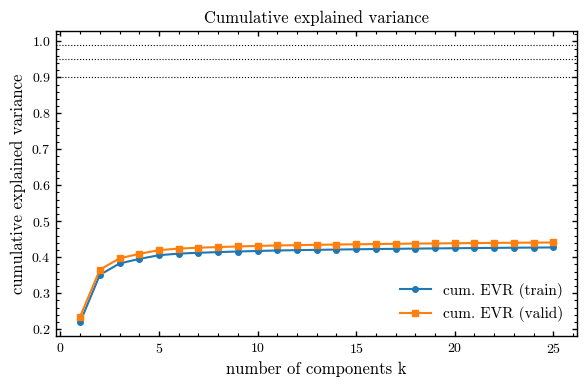

In [59]:
K_MAX = 25
kx = np.arange(1, K_MAX + 1)


for lvl in (0.90, 0.95, 0.99):
    ax.axhline(lvl, color="k", ls=":", lw=0.8)
ax.set_xlabel("number of components k")
ax.set_ylabel("cumulative explained variance")


plt.show()

In [ ]:
# valid_p99, valid_line_p99, valid_line_mean, valid_hisnr_p99

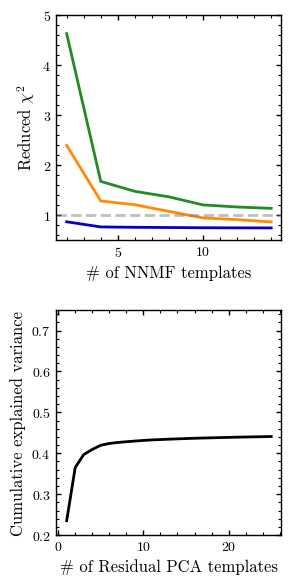

In [69]:
fig,ax = make_subplots(ncol=1,nrow=2,return_fig=True, plot_size=2.25, 
                      col_spacing=[0.5, MARGIN_PAD],
                      row_spacing=[0.6, MARGIN_SPLIT, MARGIN_PAD])

ax[1].plot(n_arr, tab["valid_mean"], color="mediumblue", lw = 2)
ax[1].plot(n_arr, tab["valid_line_mean"], color = "darkorange", lw = 2)
ax[1].plot(n_arr, tab["valid_hisnr_p99"], color = "forestgreen", lw = 2)

ax[1].set_ylim([0.5,5])

ax[1].set_xlabel("# of NNMF templates")
ax[1].set_ylabel(r"Reduced $\chi^2$")

ax[1].axhline(y=1,color="grey",alpha=0.5,ls="--",lw=2)

### pca component stuff, 
cum_evr_valid = d["cum_evr_valid"]
ax[0].plot(kx, cum_evr_valid[:K_MAX], color="k",lw=2)

ax[0].set_ylabel("Cumulative explained variance")
ax[0].set_xlabel("# of Residual PCA templates")
ax[0].set_ylim([0.2,0.75])

plt.show()

In [70]:
# what about all the line ratio variations??

## do we need PCA



## Combined NNMF + residual-PCA template scan — read of the figures

**The three metrics** (all computed on the held-out validation half — spectra the templates were never trained on):
- **global** — mean over all validation objects of the per-object reduced $\chi^2$ (all $\sim$3980 good pixels; dof = good pixels $-\,N_{\rm NMF}-\,N_{\rm PCA}$).
- **line-region** — $\chi^2$ summed *only* over pixels within $\pm$10 Å (rest-frame, vacuum) of the standard dwarf emission lines — [O II] $\lambda\lambda$3727,3730, H$\beta$ $\lambda$4863, [O III] $\lambda\lambda$4960,5008, H$\alpha$ $\lambda$6565, [S II] $\lambda\lambda$6718,6733 (113 pixels total on the $R\!\approx\!4340$ grid) — divided by the number of good line pixels. It isolates how well the templates reproduce the *emission-line* structure, independent of the continuum. (It's a $\chi^2$ per line pixel, *not* dof-reduced.)
- **hi-S/N (top 10%, mean)** — mean reduced $\chi^2$ of the 10% of objects with the highest median per-pixel S/N: "how well are the *best-measured* spectra fit?" These are the spectra where genuine structure is detectable above the noise, so this is a sensitive probe of real model inadequacy (rather than noise). We use the mean of a bright subset (more intuitive than a tail percentile); it falls as templates are added and then plateaus.

**Panel 1 ($\chi^2$ vs $N_{\rm NMF}$, no PCA).** The global mean is flat at $\sim$0.75 → the bulk population is noise-dominated (see below), so it's *evidence of noise-domination*, not the template-count lever. The line-region and hi-S/N curves fall steeply over the first $\sim$4–6 templates and flatten by $\sim$10 — the diminishing-returns "elbow" that contextualizes the production choice of 10. (Panel 1's hi-S/N curve is read from the combined grid's $N_{\rm PCA}=0$ slice, so it is the same top-10% mean shown in Panel 2.)

**Panel 2 (combined $\chi^2$ vs $N_{\rm PCA}$, one curve per $N_{\rm NMF}$, shared $y$-axis).**
- every curve **converges** as $N_{\rm PCA}$ grows → the NNMF$\leftrightarrow$PCA **tradeoff**: extra PCA components let a small NNMF basis catch up to a large one;
- the vertical gap between curves at fixed $N_{\rm PCA}$ = what extra NNMF templates buy;
- global barely moves; line-region and hi-S/N move → PCA's value is specifically **line-ratio / structured-object diversity** — a small fraction of the total variance but the science-bearing part (the *signed* PCA modes supply the line-ratio degrees of freedom a non-negative NNMF basis structurally cannot).

By $N_{\rm NMF}=10$ the residual is already nearly white: the held-out cumulative explained variance of the residual is only $\sim$0.02 at $N_{\rm PCA}=20$ (vs $\sim$0.43 at $N_{\rm NMF}=1$). So the NNMF templates capture the shared structure and PCA mops up the finer line-ratio residual.

**Why is the reduced $\chi^2 < 1$? (It is *not* over-fitting.)** Reduced $\chi^2 < 1$ means the residuals are, on average, *smaller* than the reported per-pixel noise predicts. It is **not** the model absorbing noise: there are only $\le\!20$ NNMF $+\le\!25$ PCA free coefficients per object against $\sim$3980 pixels (dof $\approx$ the pixel count), and this is measured on **held-out** spectra where the training and validation $\chi^2$ agree to $<$0.1% — an over-fit model would fit held-out data *worse* ($\chi^2$ would *rise*), not better. The real cause is that the per-pixel noise is mildly overestimated and/or neighbouring pixels are correlated: de-redshifting and resampling onto the common rest-frame grid interpolates adjacent pixels (correlating them) while the propagated inverse-variance stays diagonal, and the DESI pipeline variance is marginally conservative. Net effect: residuals sit $\sim$13% below the 1$\sigma$-per-pixel expectation → reduced $\chi^2 \approx 0.75$. The takeaway is physical: a *typical* dwarf spectrum is reproduced to within its (slightly conservative / correlated) noise by even a handful of templates — the bulk population is **noise-limited, not model-limited**, which is exactly why the informative metrics are the line region and the high-S/N subset.

Data: `scan_nnmf_ntemplates.py` (Panel 1 global/line) + `scan_nnmf_pca_grid.py` (grid + hi-S/N); submit both via `job_scripts/submit_template_scan.sh`. **Changing the hi-S/N fraction only needs a Stage-2 rerun** (no NMF retrain), since Panel 1's hi-S/N is read from the grid.

In [7]:
import numpy as np
from astropy.table import Table

SCAN_DIR = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/ntemplate_scan"

# Panel 1 data: NNMF-only scan (scan_nnmf_ntemplates.py)
tab = Table.read(f"{SCAN_DIR}/ntemplate_scan_summary.csv")
n_arr = np.array(tab["n_templates"])

# Combined (n_nmf x n_pca) grid (scan_nnmf_pca_grid.py)
gr = np.load(f"{SCAN_DIR}/nnmf_pca_grid_summary.npz")
n_nmf_grid = gr["n_nmf_grid"]
k_grid     = gr["k_grid"]

# --- hi-S/N subset selector ---------------------------------------------------
# Choose 1, 5, or 10 (%). BOTH the Panel-1 curve and the rightmost Panel-2 panel
# read this, so changing it here updates both figures consistently.
HISNR_PCT = 1
HISNR_KEY = f"hisnr_mean_top{HISNR_PCT}"
assert HISNR_KEY in gr.files, \
    f"{HISNR_KEY} not in npz (rerun scan_nnmf_pca_grid.sh?). Have: " \
    f"{[k for k in gr.files if k.startswith('hisnr')]}"

print("n_nmf grid :", n_nmf_grid)
print("n_pca grid :", k_grid[0], "..", k_grid[-1])
print("hi-S/N key :", HISNR_KEY)
# sanity: grid n_pca=0 column should match the pure-NNMF anchor (~ Panel-1 valid_mean)
print("grid k=0 global :", np.round(gr["global_redchi2_mean"][:, 0], 3))
print("pure-NNMF anchor:", np.round(gr["nmf_only_global_mean"], 3))
# residual whitening: held-out cumulative EVR of the residual at N_PCA=20 vs N_NMF.
# Drops from ~0.43 (N_NMF=1) to ~0.02 (N_NMF=10): NNMF captures the shared
# structure, leaving a near-white residual. (first_below_null in the npz is NOT
# reliable once the residual is near-white -- do not use it.)
kk = list(k_grid).index(20)
print("cum EVR(N_PCA=20):", np.round(gr["cum_evr_valid"][:, kk], 3))

n_nmf grid : [ 1  2  4  6  8 10 12 14 16 18 20]
n_pca grid : 0 .. 25
hi-S/N key : hisnr_mean_top1
grid k=0 global : [1.277 0.865 0.762 0.755 0.751 0.746 0.744 0.743 0.742 0.741 0.74 ]
pure-NNMF anchor: [1.309 0.866 0.763 0.755 0.752 0.746 0.744 0.743 0.742 0.741 0.74 ]
cum EVR(N_PCA=20): [0.431 0.157 0.042 0.033 0.028 0.021 0.019 0.017 0.016 0.015 0.014]


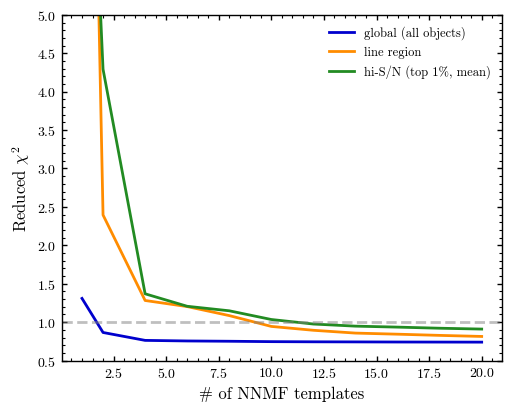

In [8]:
# Panel 1: reduced chi^2 vs number of NNMF templates (NO PCA). Extended grid.
fig, ax = plt.subplots(1, 1, figsize=(5, 4), layout="constrained")

ax.plot(n_arr, tab["valid_mean"],      color="mediumblue", lw=2, label=r"global (all objects)")
ax.plot(n_arr, tab["valid_line_mean"], color="darkorange", lw=2, label=r"line region")
# hi-S/N curve = MEAN reduced chi^2 of the top-HISNR_PCT% S/N objects, read from
# the combined grid's n_pca=0 slice (= no PCA) so it matches the panels below.
# Controlled by HISNR_PCT in the loader cell (1 / 5 / 10).
ax.plot(n_nmf_grid, gr[HISNR_KEY][:, 0], color="forestgreen", lw=2,
        label=f"hi-S/N (top {HISNR_PCT}%, mean)")

ax.axhline(1, color="grey", alpha=0.5, ls="--", lw=2)
ax.set_xlabel("# of NNMF templates")
ax.set_ylabel(r"Reduced $\chi^2$")
ax.set_ylim([0.5, 5])
ax.legend(frameon=False, fontsize=9)
plt.show()

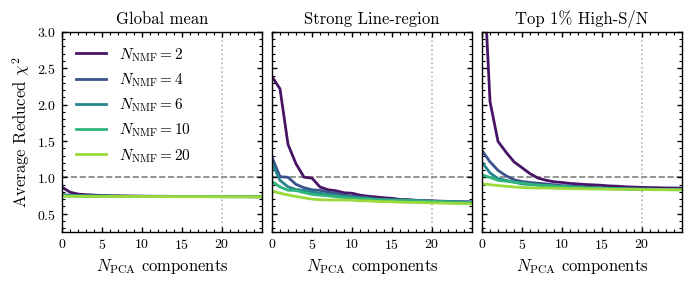

In [33]:
# --- Combined NNMF + residual-PCA reconstruction vs # PCA components ----------
# One curve per NNMF template count = horizontal slices of the (n_nmf x n_pca)
# grid (a hist2d is mostly-black here: the surface is flat except the low-N_NMF /
# low-N_PCA corner). All three panels SHARE the same y-axis so the metrics are
# directly comparable: global barely moves (noise-dominated), line-region and the
# high-S/N (top-HISNR_PCT% mean) drop, and every curve converges as N_PCA grows
# (the NNMF<->PCA tradeoff -- extra PCA lets a small NNMF basis catch up).
# The rightmost panel's S/N fraction is set by HISNR_PCT in the loader cell.
FIGDIR = SCAN_DIR   # -> point at your local paper figures/ dir when running locally

nn_list = list(n_nmf_grid)
sel = [2, 4, 6, 10, 20]
colors = plt.cm.viridis(np.linspace(0.05, 0.85, len(sel)))
curve_panels = [
    ("global_redchi2_mean", "Global mean"),
    ("line_chi2_mean",      "Strong Line-region"),
    (HISNR_KEY,             f"Top {HISNR_PCT}% High-S/N"),
]
# shared y-axis, sized from the plotted curves so it adapts to the data
_idx = [nn_list.index(nn) for nn in sel]
_ymax = max(float(np.nanmax(gr[key][_idx])) for key, _ in curve_panels)
common_ylim = [0.6, 1.05 * _ymax]

fig, ax = make_subplots(ncol=3, nrow=1, return_fig=True, plot_size=2,
                        col_spacing=[MARGIN_LABEL, MARGIN_SHARED, MARGIN_SHARED, MARGIN_PAD],
                        row_spacing=[MARGIN_LABEL, MARGIN_TICKS])
for i, (key, title) in enumerate(curve_panels):
    a = ax[i]
    for c, nn in zip(colors, sel):
        a.plot(k_grid, gr[key][nn_list.index(nn)], color=c, lw=2,
               label=fr"$N_{{\rm NMF}}={nn}$")
    a.axhline(1.0, color="0.5", ls="--", lw=1.2, zorder=0)   # chi^2 = 1
    a.axvline(20,  color="0.7", ls=":",  lw=1.2, zorder=0)   # production N_PCA = 20
    a.set_xlim(0, 25)
    # a.set_ylim(common_ylim)
    a.set_ylim([0.25,3])
    
    a.set_xticks([0, 5, 10, 15, 20])
    a.set_xlabel(r"$N_{\rm PCA}$ components")
    a.set_title(title)
    if i == 0:
        a.set_ylabel(r"Average Reduced $\chi^2$")
    else:
        a.set_yticklabels([])   # shared y-axis: labels only on the left panel
ax[0].legend(frameon=False, loc="upper left")

fig.savefig(f"{FIGDIR}/nnmf_pca_grid_curves.pdf", bbox_inches="tight")

plt.show()

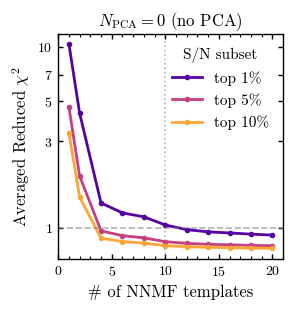

In [27]:
# --- Experimentation: how sensitive is the hi-S/N metric to the S/N fraction? --
# top 1 / 5 / 10% all come free from the same Stage-2 run (they only reselect
# objects from the same per-object chi^2). Compared (left) vs N_NMF with no PCA,
# and (right) vs N_PCA at the production N_NMF=10.
frac_curves = [("hisnr_mean_top1",  "top 1%"),
               ("hisnr_mean_top5",  "top 5%"),
               ("hisnr_mean_top10", "top 10%")]
fc = plt.cm.plasma(np.linspace(0.15, 0.8, len(frac_curves)))
gi10 = list(n_nmf_grid).index(10)

fig, ax = make_subplots(ncol=1, nrow=1, return_fig=True, plot_size=2.25,
                        col_spacing=[MARGIN_LABEL-0.35, MARGIN_PAD],
                        row_spacing=[MARGIN_LABEL-0.35, MARGIN_PAD])

for c, (key, lab) in zip(fc, frac_curves):
    ax[0].plot(n_nmf_grid, gr[key][:, 0], color=c, lw=2, marker="o", ms=3, label=lab)
for a in ax:
    a.axhline(1.0, color="grey", ls="--", lw=1.2, alpha=0.6)
    a.set_ylabel(r"Averaged Reduced $\chi^2$")
ax[0].set_xlabel("# of NNMF templates")
ax[0].set_yscale("log")
ax[0].set_xlim([0,21])

ax[0].set_title(r"$N_{\rm PCA}=0$ (no PCA)")
ax[0].legend(frameon=False, title="S/N subset")

from matplotlib.ticker import ScalarFormatter, NullLocator, FixedLocator

yticks = [1, 3, 5, 7, 10]
ax[0].yaxis.set_major_locator(FixedLocator(yticks))
ax[0].yaxis.set_minor_locator(NullLocator())        # kill the minor log ticks
ax[0].yaxis.set_major_formatter(ScalarFormatter())  # plain numbers, no sci notation
ax[0].ticklabel_format(axis="y", style="plain")     # belt-and-suspenders vs sci notation

ax[0].axvline(x=10, color="0.7", ls=":",  lw=1.2, zorder=0)

fig.savefig(f"{FIGDIR}/nnmf_grid_curves.pdf")

plt.show()